# Figure 2A–C — guide and gene modules

Groups knockouts and response genes into modules from the significant effect
size matrix, and draws the correlation structure behind them.

* **2A** knockouts embedded and coloured by guide module
* **2B** response genes embedded and coloured by gene module
* **2C** guide-guide and gene-gene correlation heatmaps, and the effect size
  matrix ordered by both

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

%matplotlib inline

sc.set_figure_params(dpi=100, fontsize=12)
sc.settings.verbosity = "hint"
sc.settings.figdir = Path("figures")
sc.settings.figdir.mkdir(exist_ok=True)

In [2]:
E3LIGASE = Path("/home/eraslab1/Projects/E3Ligase/analysisSingle")

BETA_COEFFICIENTS = E3LIGASE / "EffectSizes/MixedEffectLMOutputs/ME_SignificantBetaCoefs.csv"
GUIDE_MODULES     = E3LIGASE / "TextFiles/ME_GuideModules_leiden_6_Modules.csv"
GENE_MODULES      = E3LIGASE / "TextFiles/ME_GeneModules_leiden_11_Modules.csv"

OUTPUT_DIR = Path("outputs"); OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR = Path("figures"); FIGURE_DIR.mkdir(exist_ok=True)

# module order used when laying the heatmaps out, chosen so related
# modules sit next to each other
GUIDE_MODULE_ORDER = ["K4", "K0", "K1", "K5", "K3", "K2"]
GENE_MODULE_ORDER  = ["G6", "G9", "G10", "G5", "G4", "G7", "G0", "G1", "G3", "G2", "G8"]

CORRELATION_LIMIT = 0.5    # colour scale of the correlation heatmaps
EFFECT_LIMIT      = 0.2    # colour scale of the effect size heatmap

## Effect sizes and module assignments

The rows of the coefficient matrix are guide identifiers; only the gene name
part is kept.

In [3]:
coefsAll = pd.read_csv(BETA_COEFFICIENTS, header=0, index_col=0)
coefsAll.index = [cond.split("_")[1] for cond in coefsAll.index]

guideModules = pd.read_csv(GUIDE_MODULES, header=0, index_col=0).loc[coefsAll.index]

print(f"{coefsAll.shape[0]} knockouts x {coefsAll.shape[1]} response genes")

329 knockouts x 1041 response genes


## Guide modules — Figure 2A

computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:01)


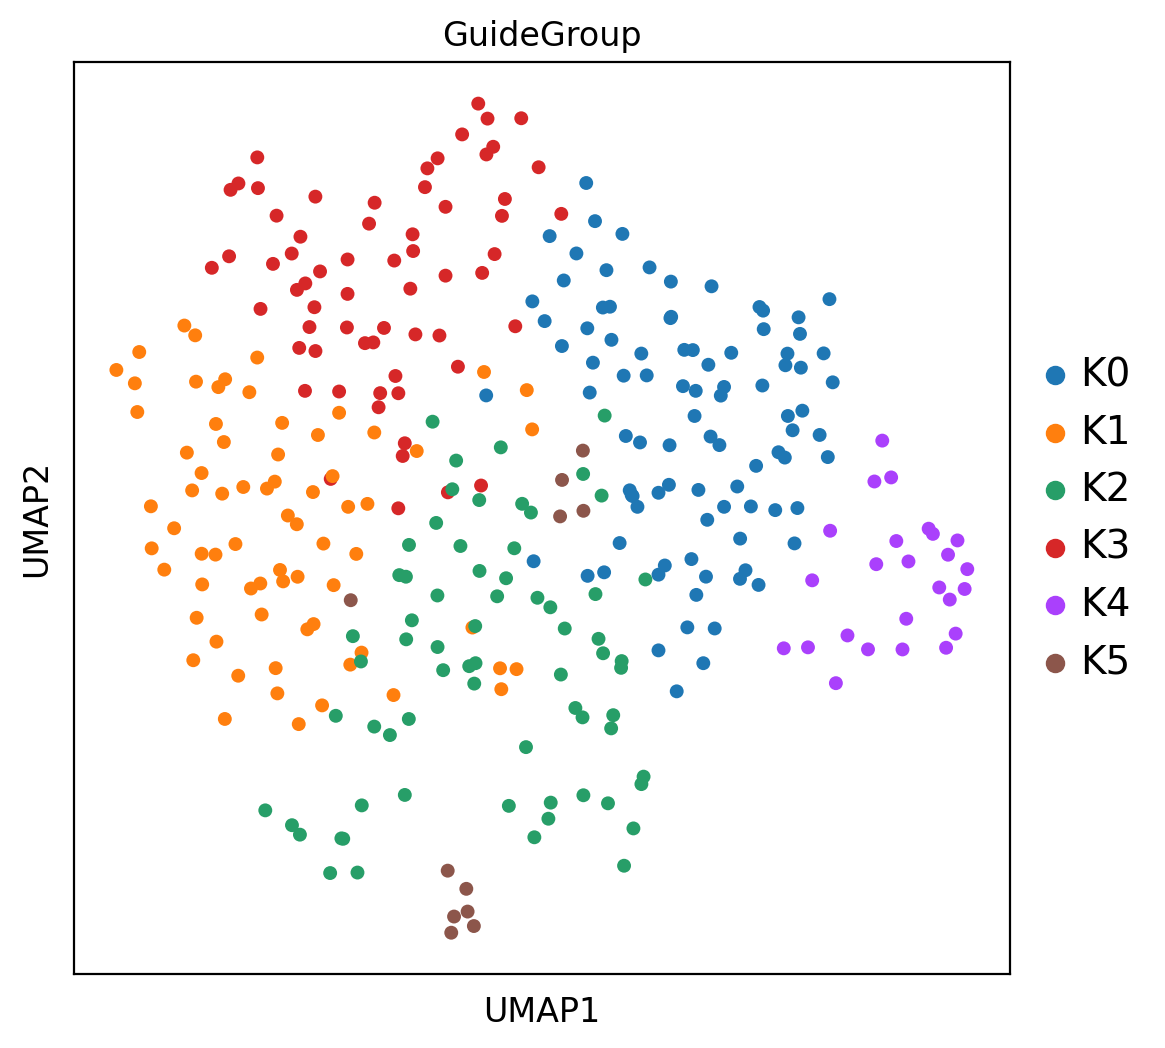

In [4]:
koGuidesAnnDat = sc.AnnData(X=coefsAll)
koGuidesAnnDat.obs["GuideGroup"] = ["K" + str(x) for x in guideModules.GuideGroup]
koGuidesAnnDat.obs["KOGenes"] = coefsAll.index

sc.pp.pca(koGuidesAnnDat, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(koGuidesAnnDat, n_neighbors=15, metric="euclidean")
sc.tl.umap(koGuidesAnnDat)

f, ax = plt.subplots(figsize=(6, 6))
sc.pl.umap(
    koGuidesAnnDat, color="GuideGroup", ax=ax, size=100,
    legend_fontoutline=3, legend_fontsize=14, legend_loc="right margin",
    legend_fontweight="normal", save="Figure_2A.pdf",
)

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_GuideGroup']`


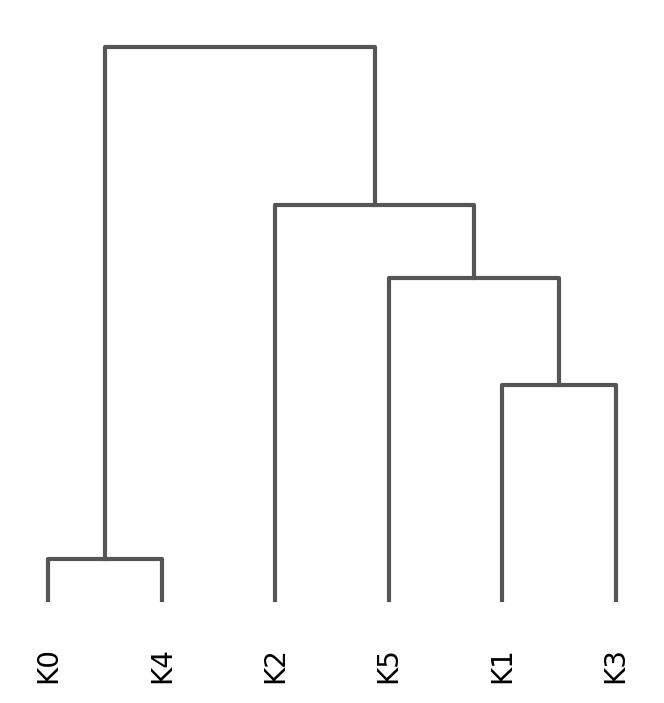

<AxesSubplot:>

In [5]:
sc.tl.dendrogram(koGuidesAnnDat, groupby="GuideGroup")
sc.pl.dendrogram(koGuidesAnnDat, groupby="GuideGroup")

## Guide-guide correlation — Figure 2C (left)

Knockouts are laid out module by module, each module keeping the colour scanpy
gave it in the embedding above.

In [6]:
guideModules = koGuidesAnnDat.obs[["KOGenes", "GuideGroup"]]
guideModules.columns = ["GuideName", "GuideGroup"]
guideModules = guideModules.sort_values(["GuideGroup", "GuideName"])

# lay the modules out in the chosen order
guideModules = pd.concat(
    [guideModules.loc[guideModules.GuideGroup == group] for group in GUIDE_MODULE_ORDER]
)

# reuse the embedding's palette so the heatmap bars match Figure 2A
palette = koGuidesAnnDat.uns["GuideGroup_colors"]
guideModules["GuideColor"] = [
    palette[int(group[1:])] for group in guideModules.GuideGroup
]

guideCov = pd.DataFrame(np.corrcoef(coefsAll), index=coefsAll.index, columns=coefsAll.index)
guideCov = guideCov.loc[guideModules.GuideName, guideModules.GuideName]

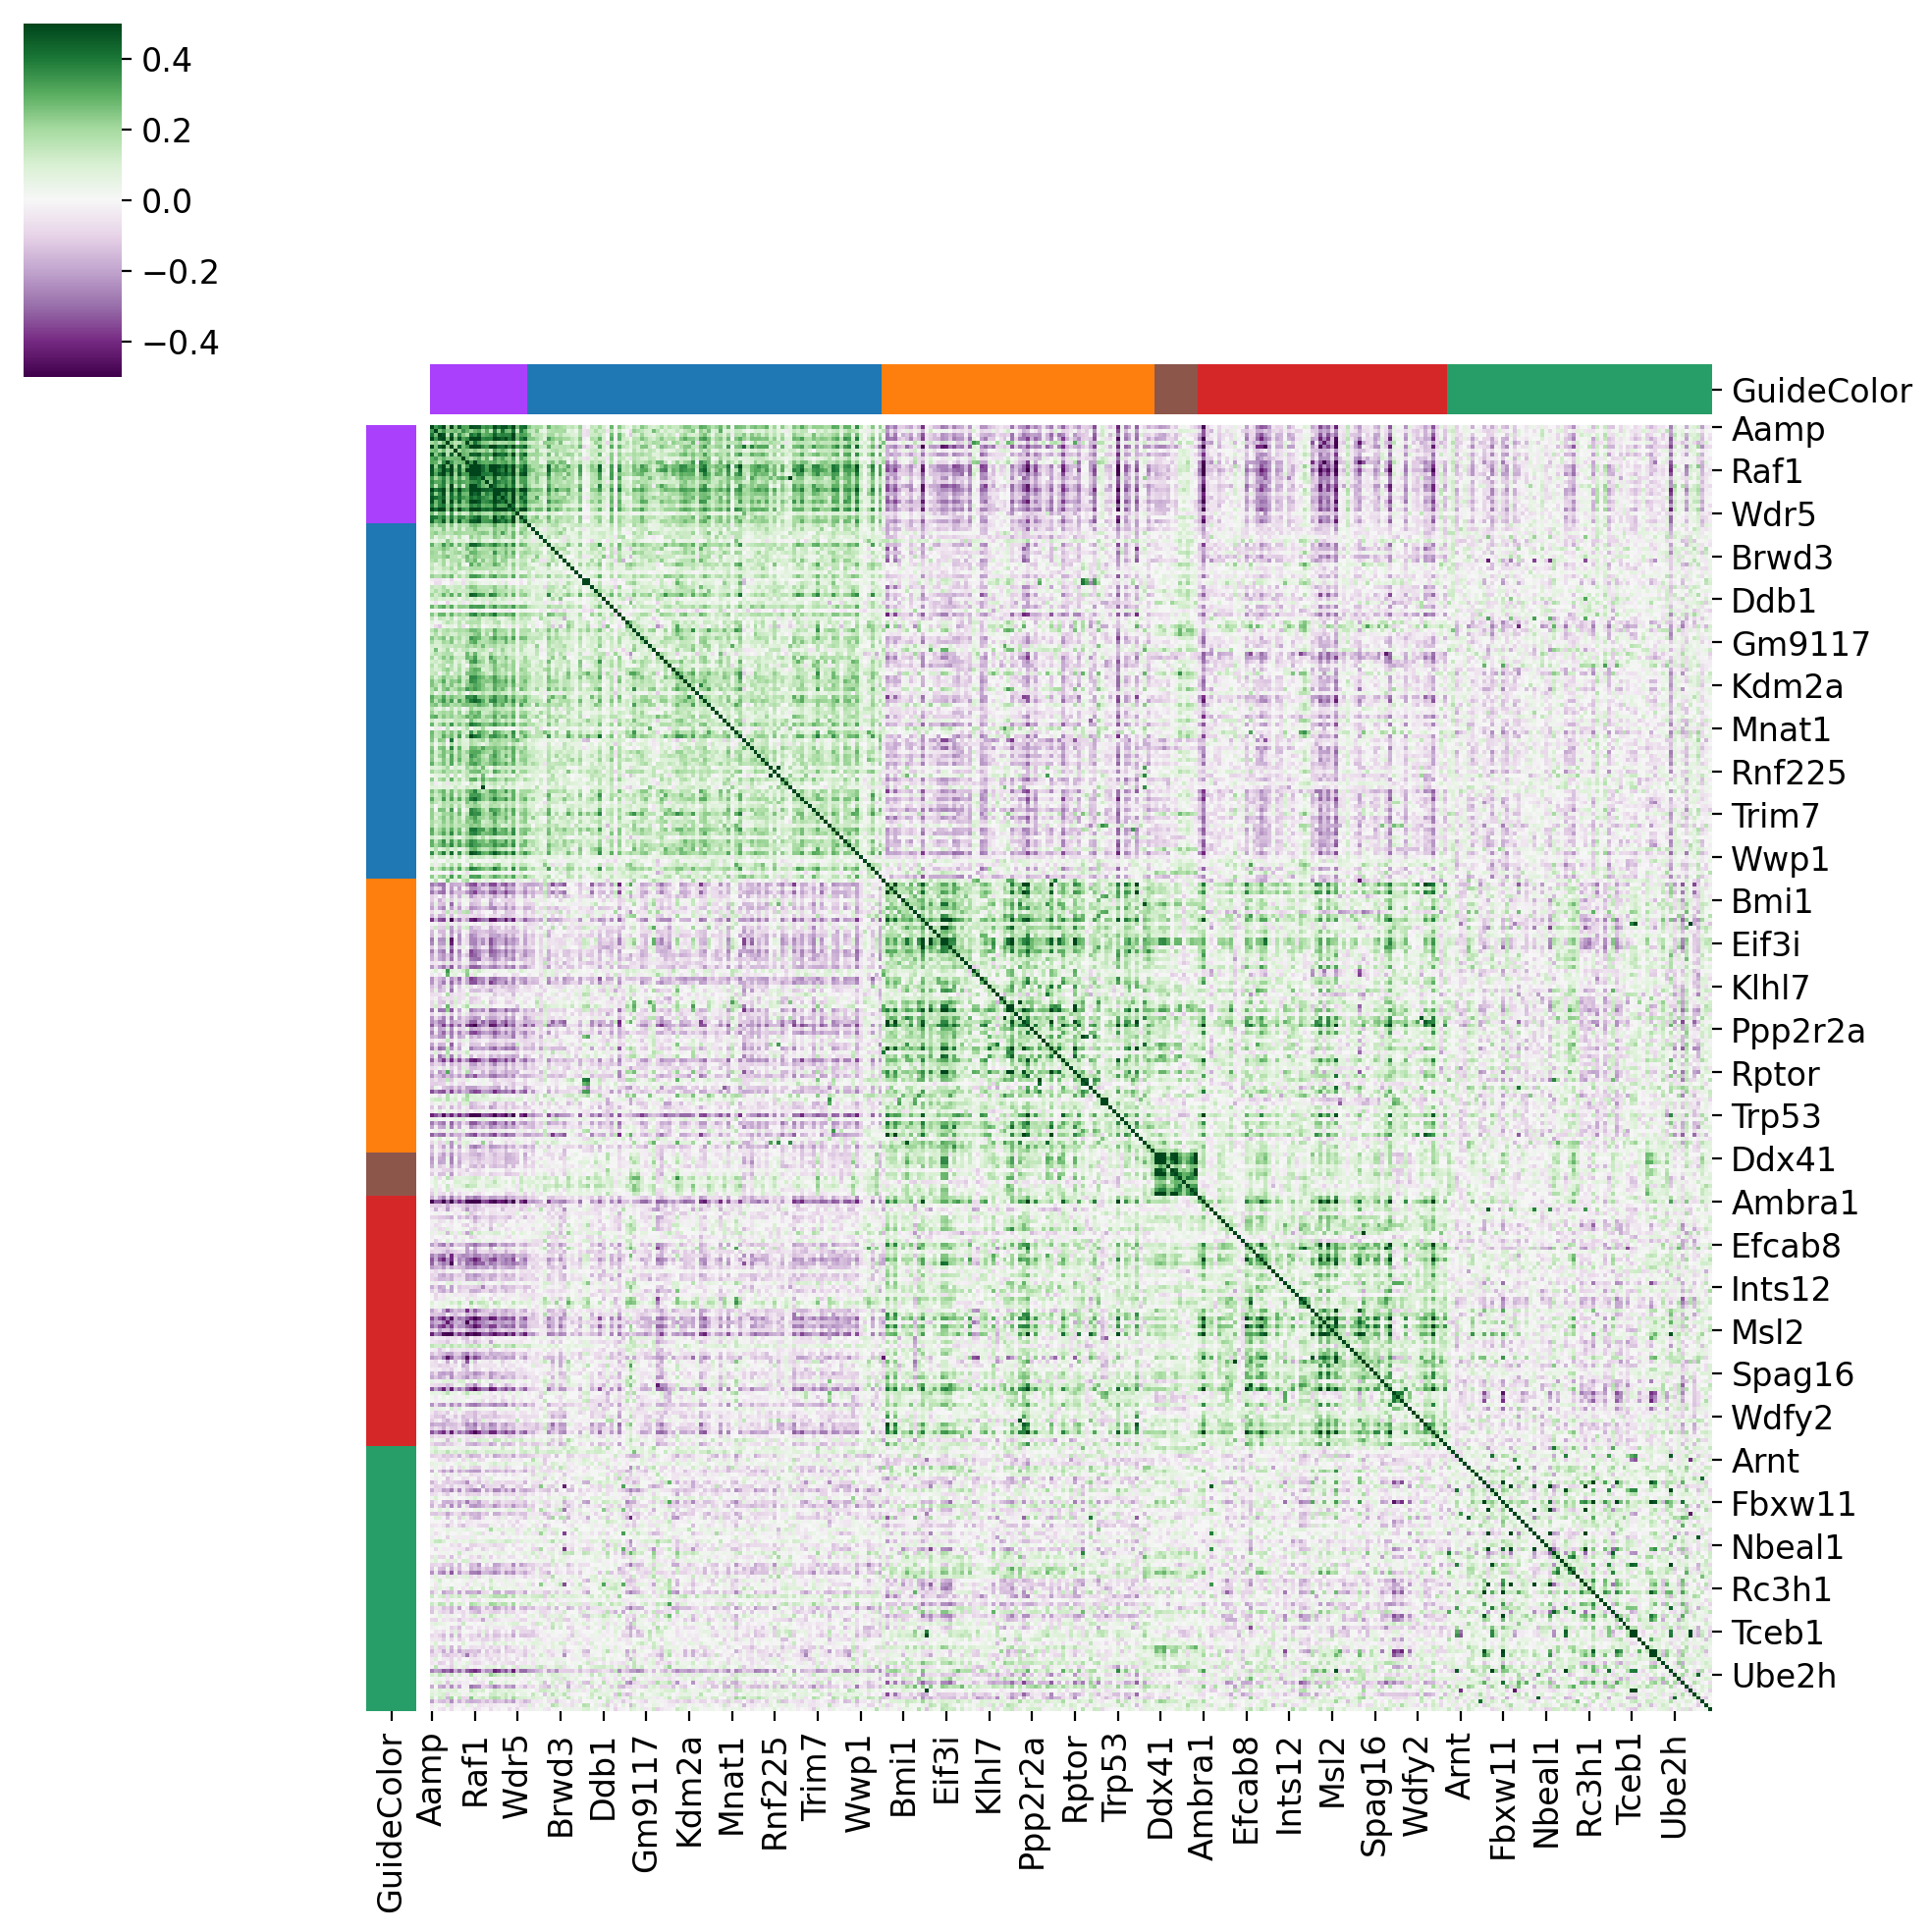

In [7]:
sns.clustermap(
    guideCov, row_cluster=False, col_cluster=False, cmap=plt.cm.PRGn,
    vmin=-CORRELATION_LIMIT, vmax=CORRELATION_LIMIT,
    row_colors=guideModules.GuideColor, col_colors=guideModules.GuideColor,
)
plt.savefig(FIGURE_DIR / "Figure_2C_1.pdf", dpi=300)

## Gene modules — Figure 2B

computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:01)


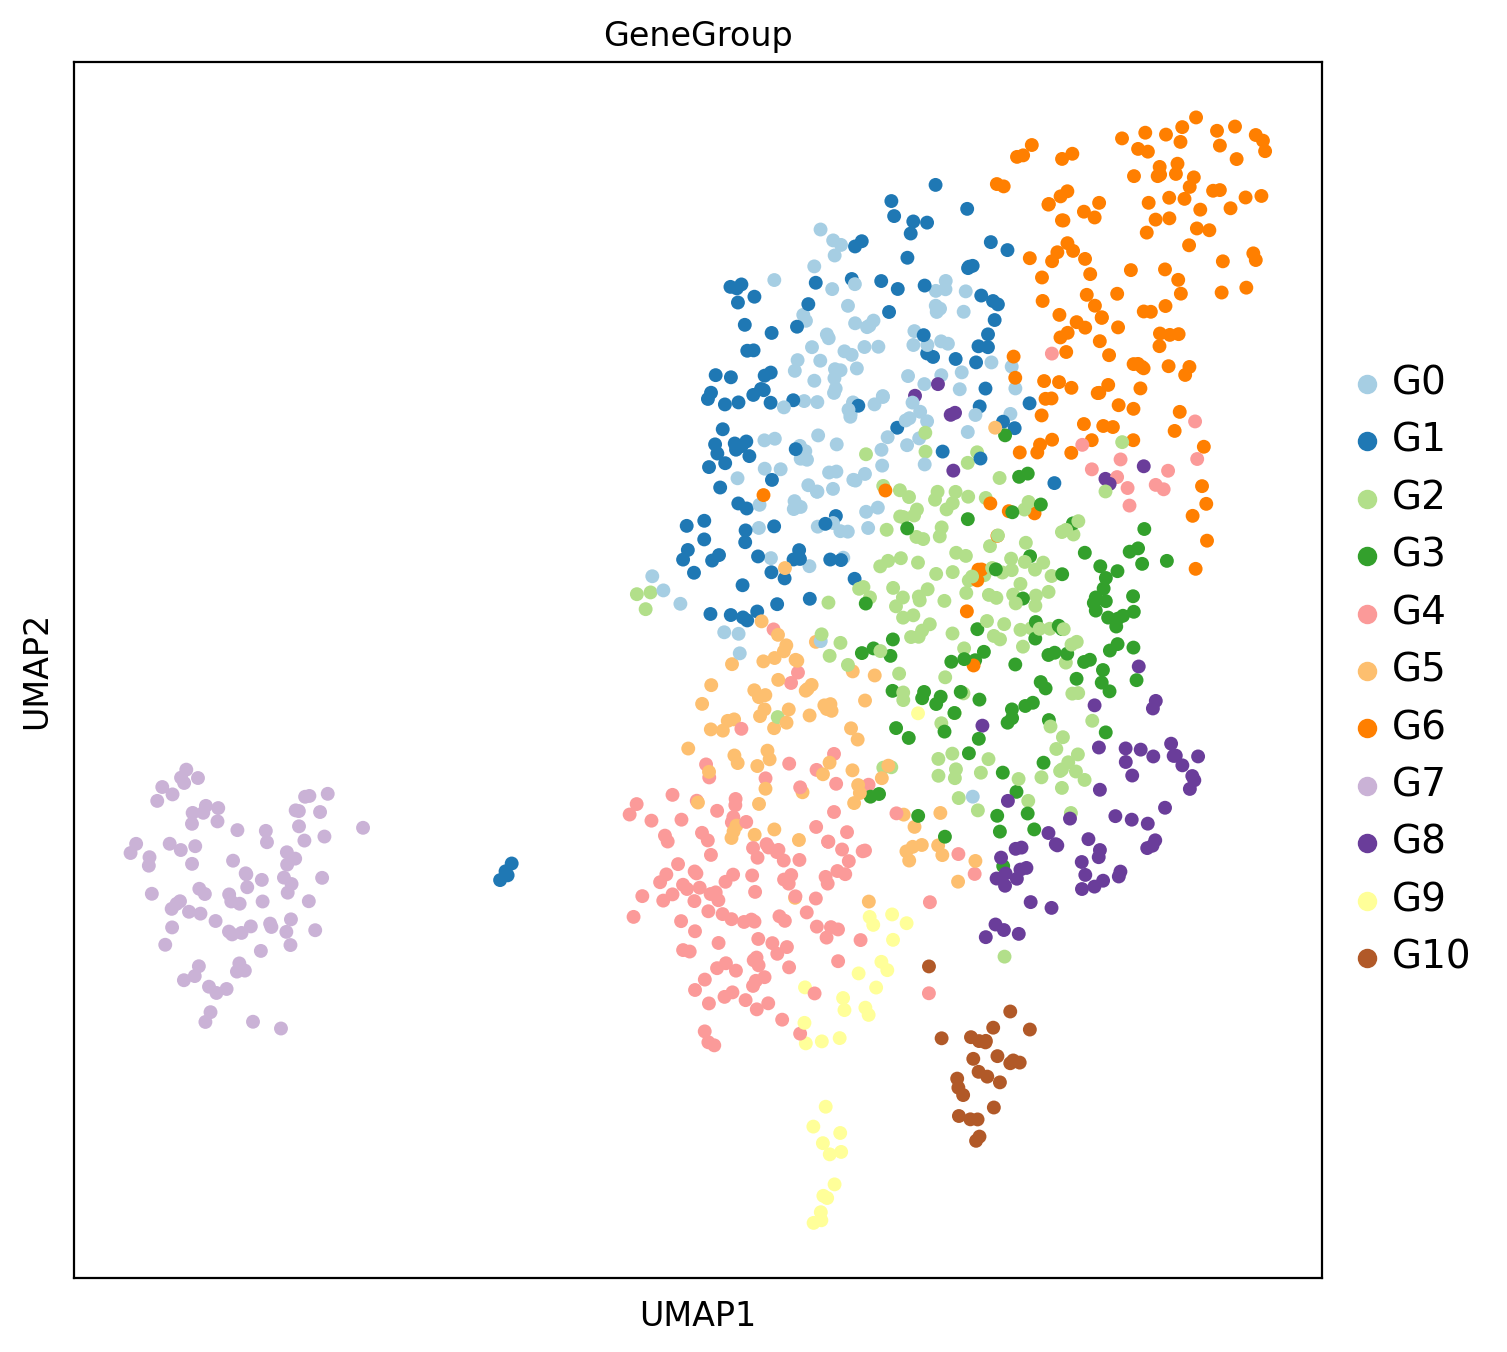

In [8]:
geneModules = pd.read_csv(GENE_MODULES, header=0, index_col=None)
geneModules.index = geneModules.GeneName
geneModules = geneModules.loc[coefsAll.columns]

koGenesAnnDat = sc.AnnData(X=coefsAll.transpose())
koGenesAnnDat.obs["GeneGroup"] = [str(x) for x in geneModules.GeneGroup]
koGenesAnnDat.obs["EffectedGenes"] = coefsAll.columns

sc.pp.pca(koGenesAnnDat, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(koGenesAnnDat, n_neighbors=4, metric="euclidean")
sc.tl.umap(koGenesAnnDat)

f, ax = plt.subplots(figsize=(8, 8))
sc.pl.umap(
    koGenesAnnDat, color="GeneGroup", ax=ax, size=100, palette="Paired",
    legend_fontoutline=3, legend_fontsize=14, legend_loc="right margin",
    legend_fontweight="normal", save="Figure_2B_3.pdf",
)

## Gene-gene correlation — Figure 2C (middle)

:::{note}
The module file is re-read here in its original row order, and that order is
what the heatmap below uses. The re-ordered copy is written to `outputs/` but
does not drive the figure; this matches the original notebook.
:::

In [9]:
geneModules = pd.read_csv(GENE_MODULES, header=0, index_col=None)

geneModulesOrdered = pd.concat(
    [geneModules.loc[geneModules.GeneGroup == group] for group in GENE_MODULE_ORDER]
)
geneModulesOrdered.to_csv(OUTPUT_DIR / "ME_GeneModules_leiden_11_Modules.csv", index=False)

geneCov = pd.DataFrame(
    np.corrcoef(coefsAll.transpose()), index=coefsAll.columns, columns=coefsAll.columns
)
geneCov = geneCov.loc[geneModules.GeneName, geneModules.GeneName]

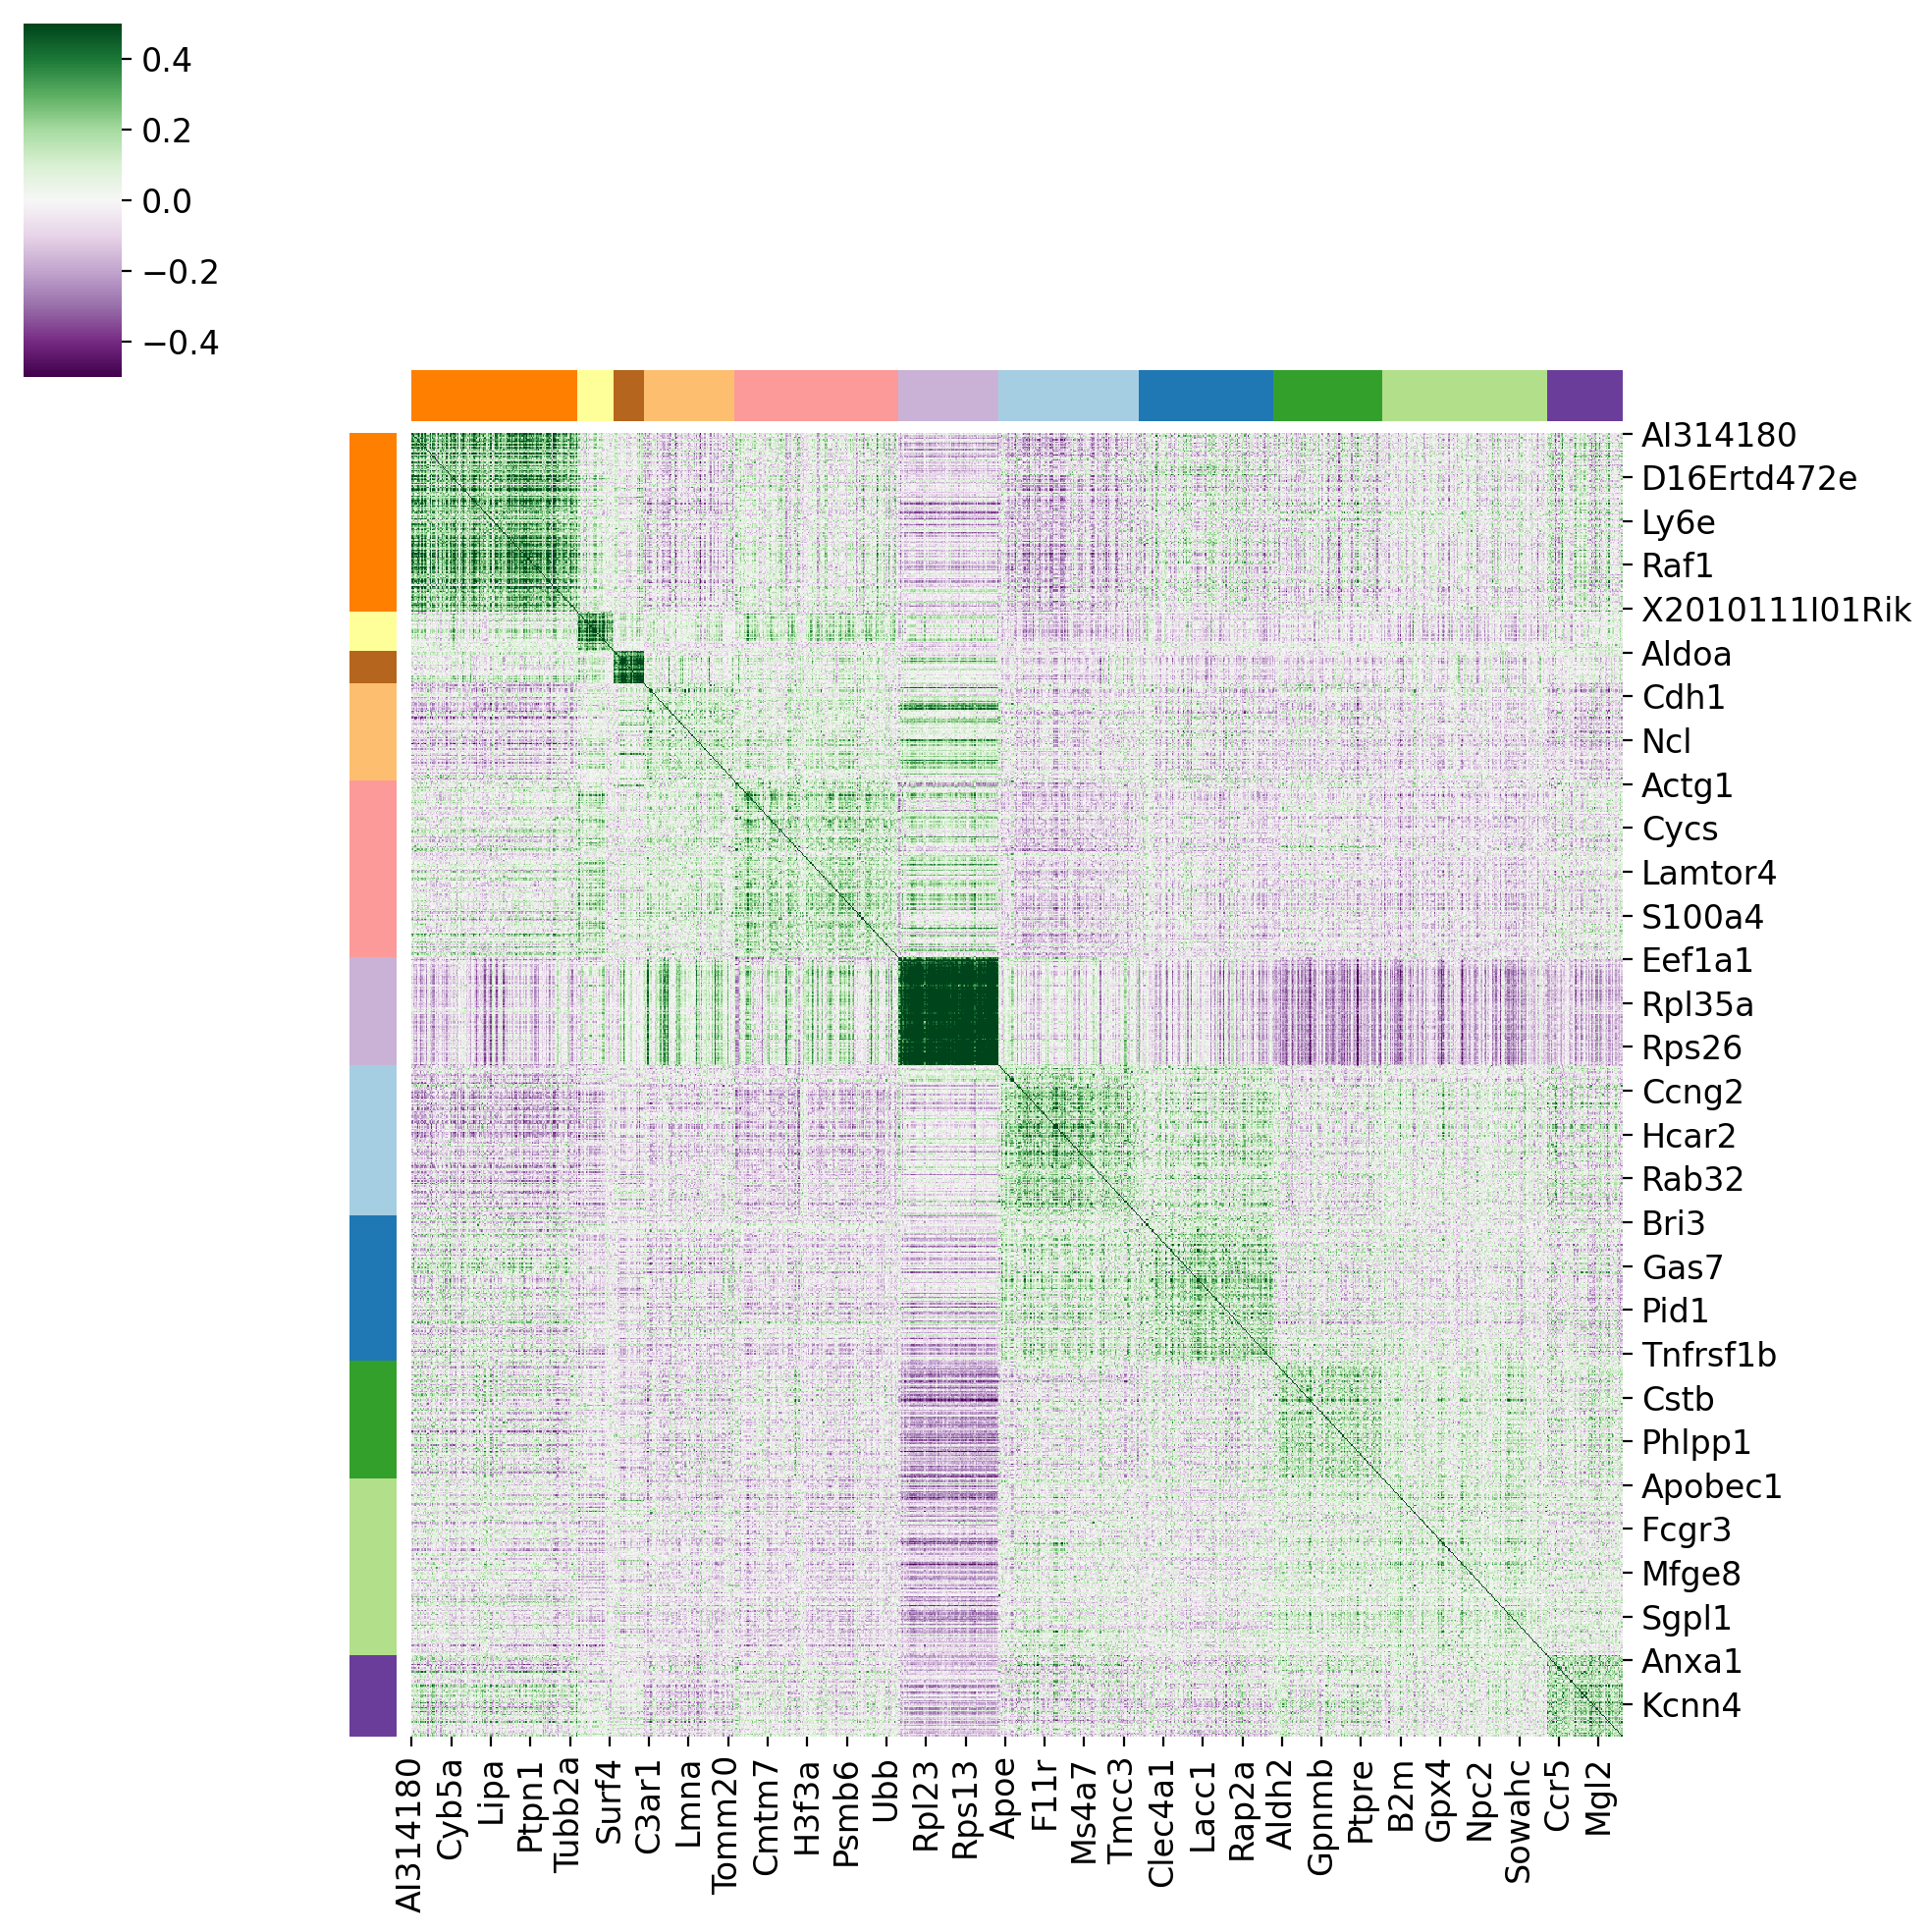

In [10]:
sns.clustermap(
    geneCov, row_cluster=False, col_cluster=False, cmap=plt.cm.PRGn,
    vmin=-CORRELATION_LIMIT, vmax=CORRELATION_LIMIT,
    row_colors=list(geneModules.GeneColor), col_colors=list(geneModules.GeneColor),
)
plt.savefig(FIGURE_DIR / "Figure_2C_2.pdf", dpi=300)

## Effect sizes ordered by both module sets — Figure 2C (right)

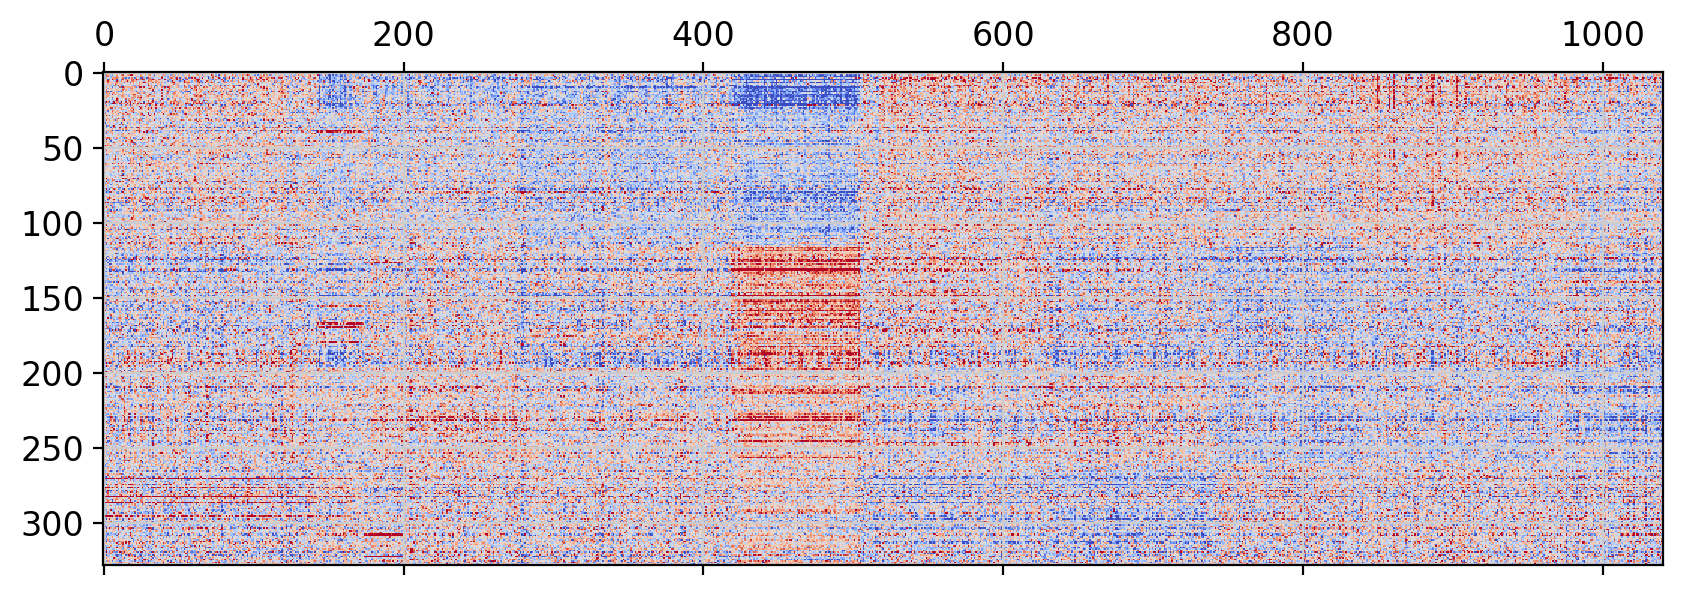

In [11]:
orderedEffects = coefsAll.loc[guideCov.index, geneCov.index]

fig, ax = plt.subplots(figsize=(10, 10))
ax.matshow(orderedEffects, cmap=plt.cm.coolwarm, vmin=-EFFECT_LIMIT, vmax=EFFECT_LIMIT)

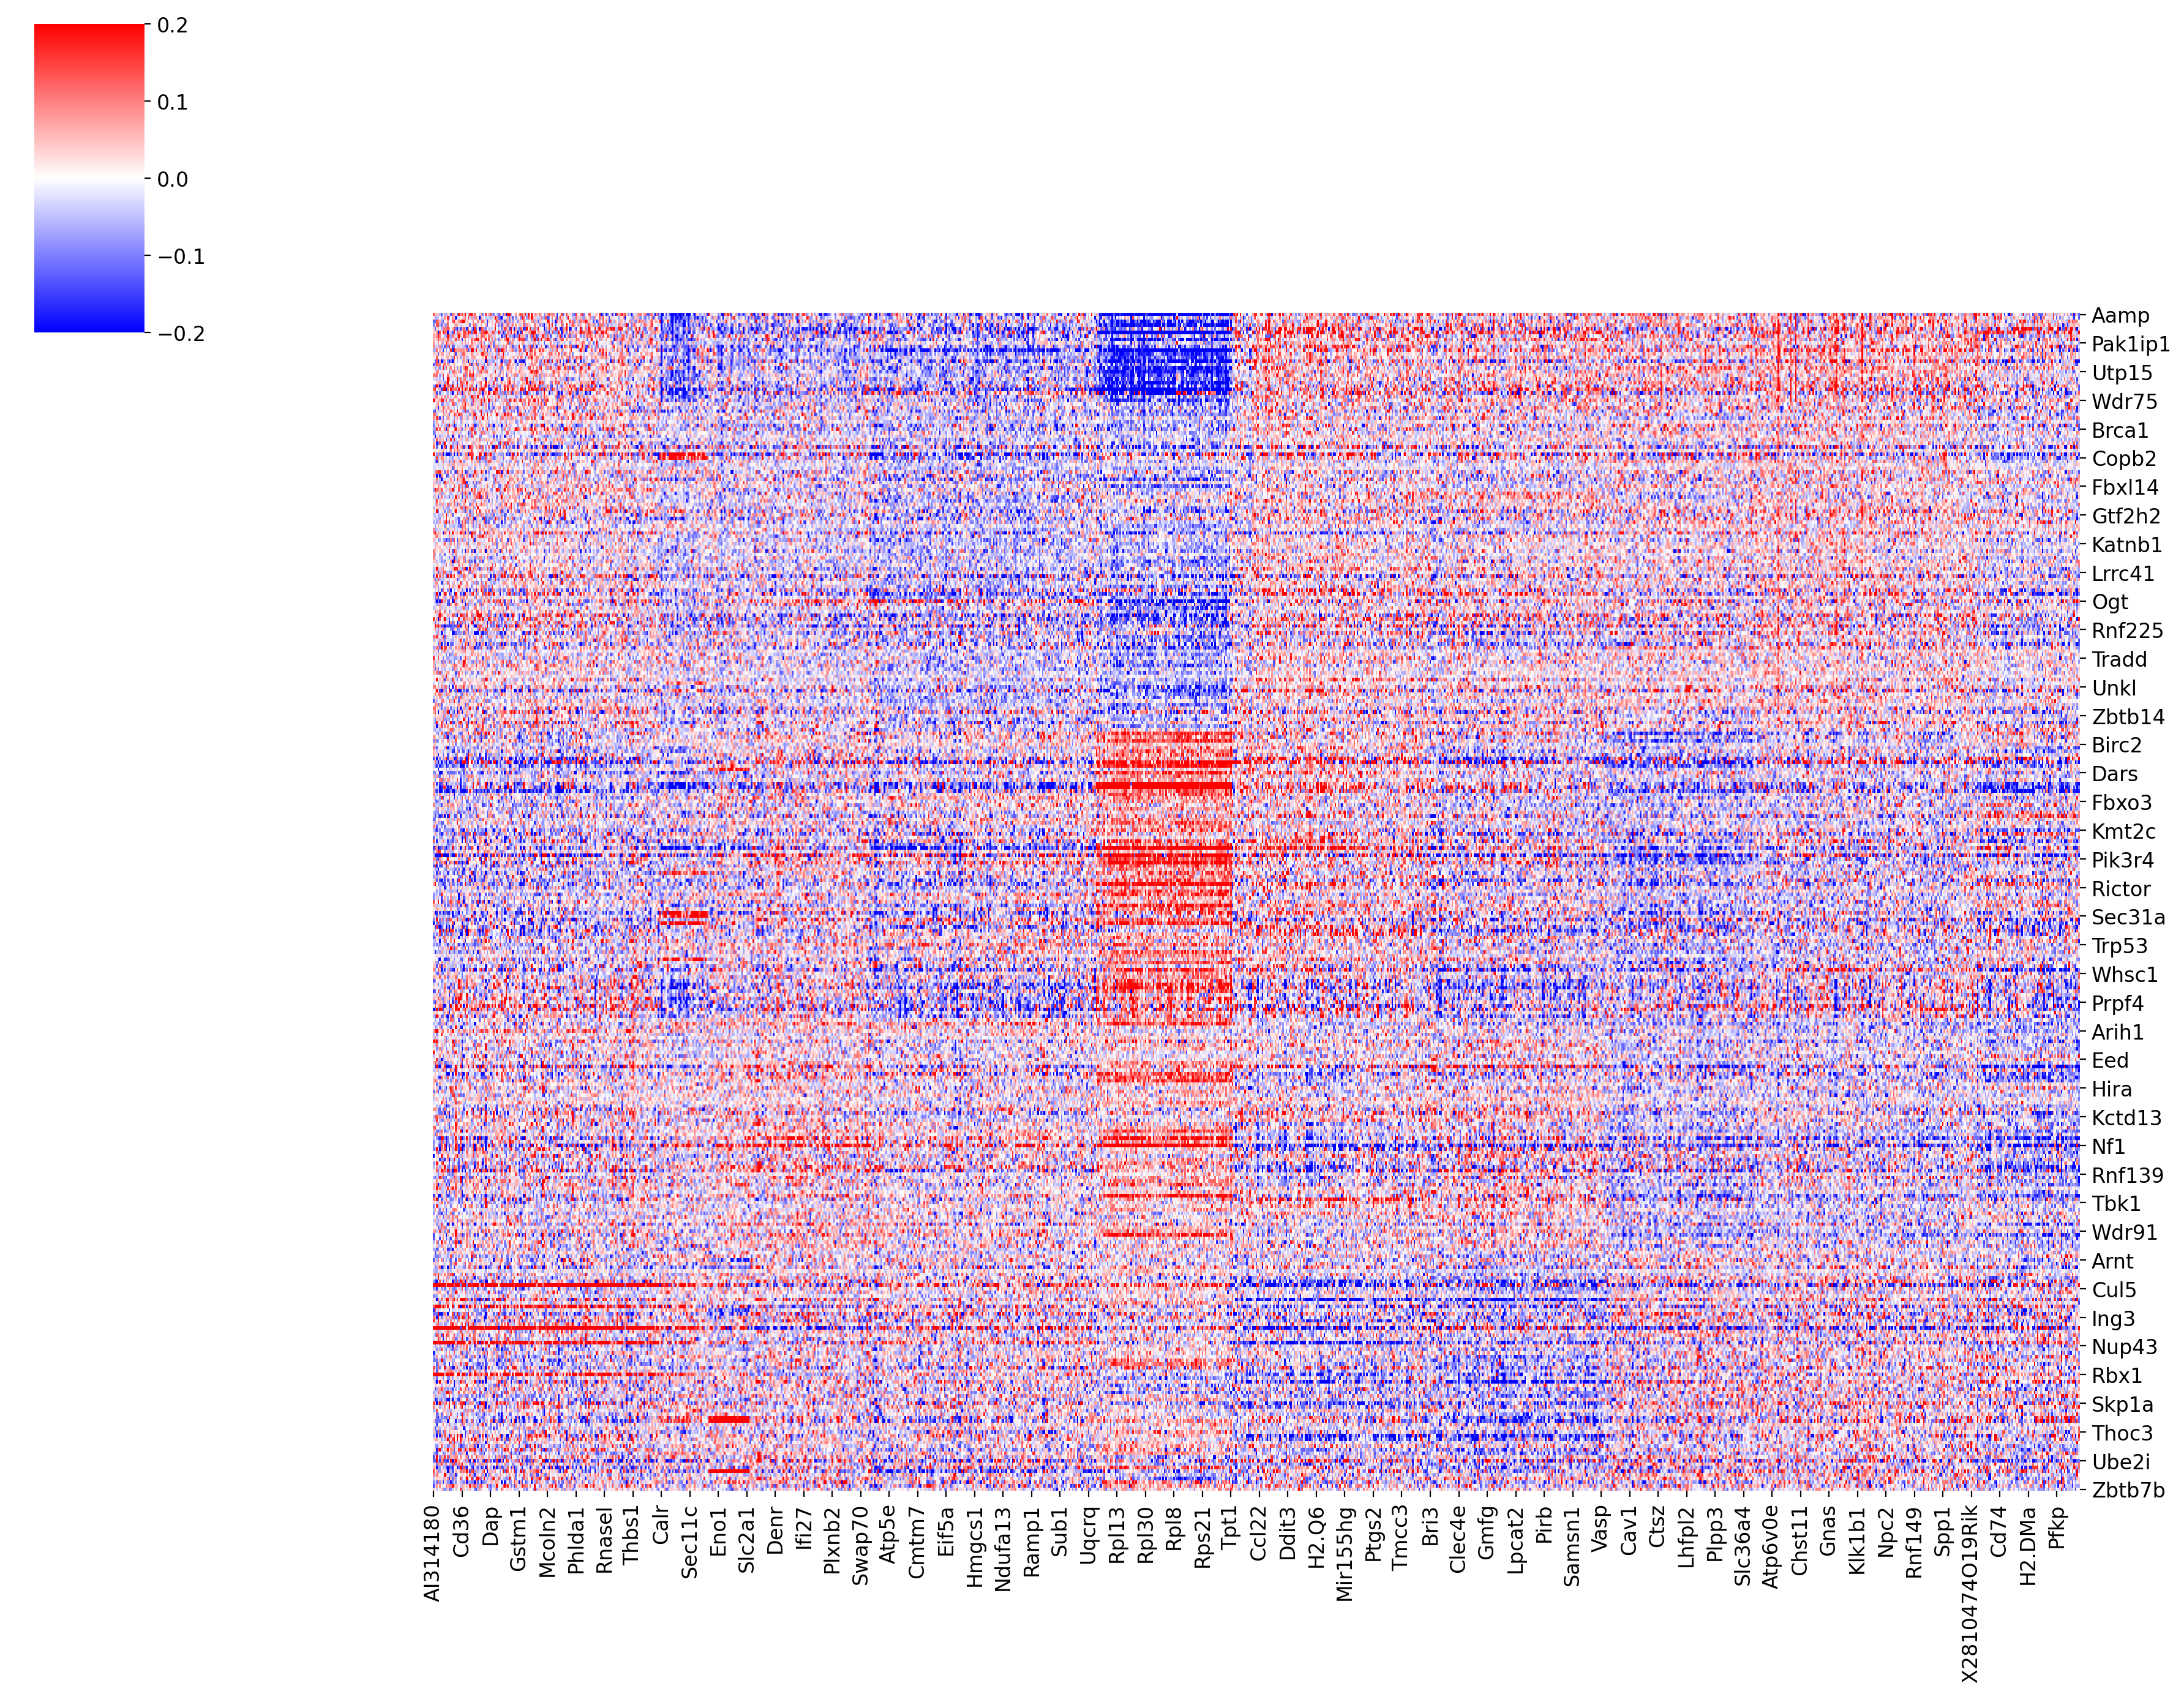

In [12]:
sns.clustermap(
    orderedEffects, row_cluster=False, col_cluster=False, cmap=plt.cm.bwr,
    vmin=-EFFECT_LIMIT, vmax=EFFECT_LIMIT, figsize=(18, 14),
)
plt.savefig(FIGURE_DIR / "Figure_2C_3.pdf", dpi=300)